### By Thanh Pham tp25449

# Section 1: Introduction & Model Selection

In this project, a spring-mass-damper system was used to model a simplified quarter-car suspension system. This type of model is commonly used in mechanical and automotive engineering to study how vehicles respond to road disturbances such as potholes or speed bumps. The system consists of a mass attached to a spring and damper, where the spring provides a restoring force and the damper dissipates energy through resistive forces. The purpose of this model is to analyze how the displacement of the mass changes over time and to investigate the stability and accuracy of numerical methods used to solve the governing differential equation.

The motion of the system is governed by the second-order ordinary differential equation

$$
m y'' + c y' + ky = 0
$$

where $y(t)$ represents the vertical displacement of the mass from equilibrium. The parameter $m$ is the mass measured in kilograms $(\mathrm{kg})$, $c$ is the damping coefficient measured in newton-seconds per meter $(\mathrm{N \cdot s/m})$, and $k$ is the spring constant measured in newtons per meter $(\mathrm{N/m})$. The term $my''$ represents inertia, $cy'$ represents damping forces from the shock absorber, and $ky$ represents the restoring force from the spring.

To apply numerical methods such as Euler’s Method and the fourth-order Runge-Kutta method, the second-order differential equation was converted into a system of first-order differential equations.

Let

$$
y_1 = y
$$

and

$$
y_2 = y'
$$

Then the system becomes

$$
y_1' = y_2
$$

and

$$
y_2' = -\frac{c}{m}y_2 - \frac{k}{m}y_1.
$$

In this formulation, $y_1$ represents displacement and $y_2$ represents velocity. Converting the equation into this form allows the numerical methods to update both displacement and velocity step-by-step throughout the simulation.

---

# Section 2: Parameter Research & Justification

The spring-mass-damper system was modeled using parameters representative of a quarter-car suspension system. Typical quarter-car suspension systems commonly use sprung masses in the range of $200\text{–}400\,\mathrm{kg}$, suspension stiffness values between $10^4$ and $10^5\,\mathrm{N/m}$, and damping coefficients on the order of $10^3\,\mathrm{N \cdot s/m}$, so the values used in this project were selected to remain within realistic engineering ranges discussed in <i>Fundamentals of Vehicle Dynamics</i> by Thomas D. Gillespie.

| Parameter | Meaning | Value | Units |
|---|---|---|---|
| $m$ | Mass | $250$ | $\mathrm{kg}$ |
| $c$ | Damping coefficient | $1000$ | $\mathrm{N \cdot s/m}$ |
| $k$ | Spring constant | $15000$ | $\mathrm{N/m}$ |

The chosen values produce an underdamped system, which is physically realistic for vehicle suspension systems because the oscillations should gradually decay after a disturbance rather than continue indefinitely or stop immediately.

The initial conditions used in the simulation were

$$
y(0) = 0.10 \text{ m}
$$

and

$$
y'(0) = 0 \text{ m/s}.
$$

These initial conditions represent a sudden vertical displacement of the suspension system with no initial velocity, similar to a vehicle encountering a speed bump and then being released. The displacement of $0.10\,\mathrm{m}$ was chosen to create a noticeable oscillatory response while remaining within a physically reasonable range for suspension motion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Spring-mass-damper parameters
m = 250.0      # mass, kg
c = 1000.0     # damping coefficient, N*s/m
k = 15000.0    # spring constant, N/m

# Initial conditions
y0 = 0.10      # initial displacement, m
v0 = 0.0       # initial velocity, m/s

# Time interval
t_start = 0.0
t_end = 10.0

In [3]:
# my" + cy' + ky = 0 
# 2nd Order ODE broken down in a linear system
def f(y, v): 
    dydt = v
    dvdt = -(c / m) * v - (k / m) * y
    return dydt, dvdt

# Section 3: Numerical Methods Implementation

The second-order ODE was solved using Euler’s Forward Method and the fourth-order Runge-Kutta method. Both methods update displacement and velocity at each time step after converting the equation into a first-order system.

In [4]:
def euler_method(h, m, c, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
#Creates empty arrays to store approximations of our solution
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        
        
        dydt, dvdt = f(y_n,v_n)


        # Euler updates
        y_values[i] = y_n + h * dydt
        v_values[i] = v_n + h * dvdt

    return t_values, y_values, v_values


In [5]:
def rk4(m, c, k, y0, v0, t0, tf, h):
    #Implements the fourth order Runge Kutta approximation method
    
    t_values = np.arange(t0, tf + h, h)

    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    y_values[0] = y0
    v_values[0] = v0

    for i in range(1, len(t_values)):
        
        #Iteratively calculates the 4 slopes
        t = t_values[i - 1]
        y = y_values[i - 1]
        v = v_values[i - 1]

        
        k1_y, k1_v = f(y, v)

        k2_y, k2_v = f(
            y + h * k1_y / 2,
            v + h * k1_v / 2
        )

        k3_y, k3_v = f(
            y + h * k2_y / 2,
            v + h * k2_v / 2
        )

        k4_y, k4_v = f(
            y + h * k3_y,
            v + h * k3_v
        )
        
        #passes the weighted average of the slopes into the array

        y_values[i] = y + (h / 6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
        v_values[i] = v + (h / 6) * (k1_v + 2*k2_v + 2*k3_v + k4_v)

    return t_values, y_values, v_values

In [6]:
step_sizes = [0.001, 0.005, 0.01, 0.05,0.075,0.1 , 0.25, 0.5]

results = []

#Solves our ODE using the two methods implemented
for h in step_sizes:
    t_euler, y_euler, v_euler = euler_method(h, m, c, k, t_start, t_end, y0, v0)

    t_rk4, y_rk4, v_rk4 = rk4(m, c, k, y0, v0, t_start, t_end, h)

    results.append([
        h,
        (t_euler, y_euler, v_euler),
        (t_rk4, y_rk4, v_rk4)
    ])

# Section 4: Solutions & Comparison

The spring-mass-damper system was solved using both Euler’s Forward Method and the fourth-order Runge-Kutta (RK4) method for several different step sizes. The numerical solutions were compared using displacement-versus-time plots, velocity-versus-time plots, and phase portraits in order to study the stability and accuracy of each method.

For smaller step sizes ranging from \(h = 0.001\) to approximately \(h = 0.05\), both numerical methods produced stable solutions that followed the expected damped oscillatory motion of the physical system. Euler’s Method produced slight variations between solutions as the step size increased, indicating the accumulation of numerical error. Although the solutions remained stable in this range, the damping behavior and amplitudes changed slightly between different step sizes. In contrast, the RK4 solutions for these same step sizes were nearly identical and closely matched the analytical solution, showing that RK4 maintained significantly higher accuracy.

As the step size increased beyond the stable range for Euler’s Method, the numerical solutions became unstable. Euler’s Method began producing stiff and flattened solution curves that no longer accurately represented the oscillatory behavior of the spring-mass-damper system. The numerical damping became excessively large, causing the motion to decay unrealistically fast and lose important features of the physical system.

The RK4 method behaved differently for larger step sizes. While RK4 eventually showed instability for sufficiently large values of h, it remained stable for much larger step sizes than Euler’s Method. Even when Euler’s Method had already become unstable, RK4 continued to produce reasonable damped oscillations that matched the expected physical behavior of the system. This demonstrates the improved stability properties of RK4 compared to Euler’s Method.

The velocity-versus-time plots showed similar behavior. Stable simulations produced smooth decaying oscillations in velocity, while unstable Euler simulations distorted the physical motion of the system. The phase portraits also illustrated these differences clearly. For stable simulations, the trajectories spiraled inward toward the equilibrium point at \((0,0)\), representing the gradual loss of energy caused by damping. When instability occurred, the phase portraits distorted and no longer followed the expected inward spiral behavior.

Overall, the comparison showed that RK4 was substantially more accurate and stable than Euler’s Method for this problem. Euler’s Method required very small step sizes to maintain reliable behavior, while RK4 remained accurate and stable over a much wider range of step sizes.

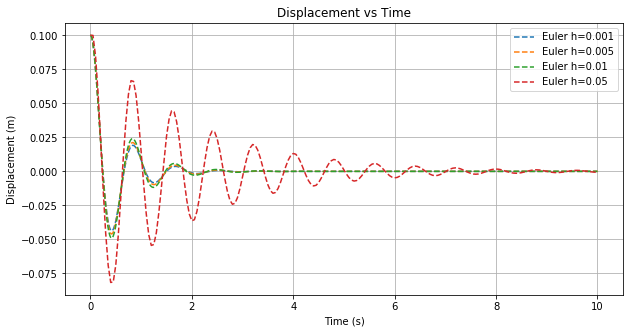

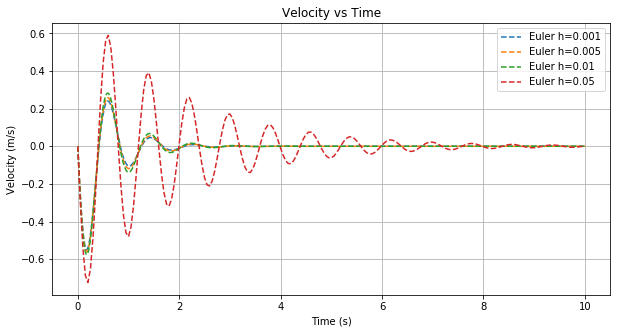

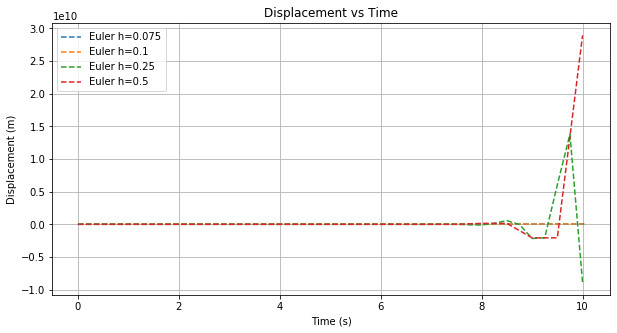

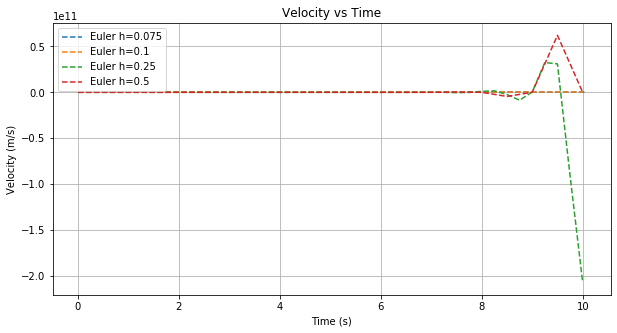

In [7]:
# Create first figure
plt.figure(figsize=(10, 5))

# Create second figure
plt.figure(figsize=(10, 5))

for result in results[:len(results)//2]:

    h = result[0]

    t_euler, y_euler, v_euler = result[1]

    plt.figure(1)
    plt.plot(t_euler, y_euler, linestyle="--", label=f"Euler h={h}")
    
    plt.figure(2)
    plt.plot(t_euler, v_euler, linestyle="--", label=f"Euler h={h}")

plt.figure(1)
plt.title("Displacement vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)

plt.figure(2)

plt.title("Velocity vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)


plt.show()


# Create first figure
plt.figure(figsize=(10, 5))

# Create second figure
plt.figure(figsize=(10, 5))

for result in results[len(results)//2:]:

    h = result[0]

    t_euler, y_euler, v_euler = result[1]

    plt.figure(1)
    plt.plot(t_euler, y_euler, linestyle="--", label=f"Euler h={h}")
    
    plt.figure(2)
    plt.plot(t_euler, v_euler, linestyle="--", label=f"Euler h={h}")

plt.figure(1)
plt.title("Displacement vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)

plt.figure(2)

plt.title("Velocity vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)


plt.show()

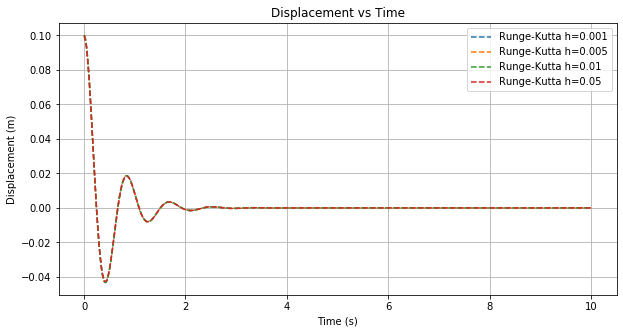

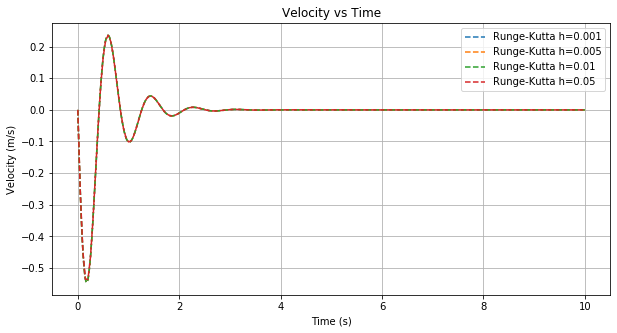

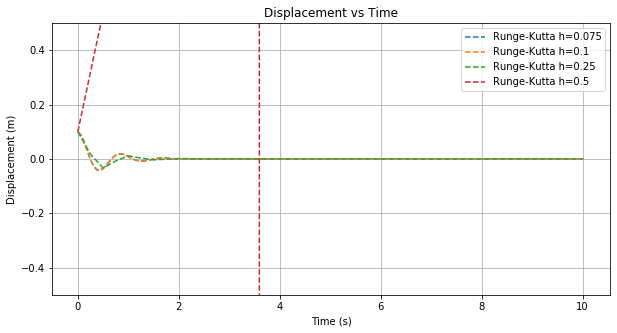

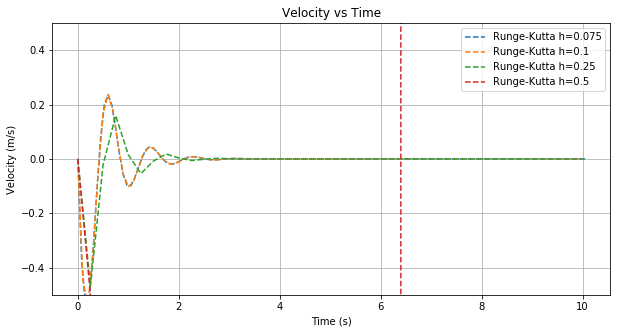

In [8]:
# Create first figure
plt.figure(figsize=(10, 5))

# Create second figure
plt.figure(figsize=(10, 5))

for result in results[:len(results)//2]:

    h = result[0]

    t_rk4, y_rk4, v_rk4 = result[2]

    plt.figure(1)
    plt.plot(t_rk4, y_rk4, linestyle="--", label=f"Runge-Kutta h={h}")
    
    plt.figure(2)
    plt.plot(t_rk4, v_rk4, linestyle="--", label=f"Runge-Kutta h={h}")

plt.figure(1)
plt.title("Displacement vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.legend()
plt.grid(True)

plt.figure(2)

plt.title("Velocity vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)


plt.show()


# Create first figure
plt.figure(figsize=(10, 5))

# Create second figure
plt.figure(figsize=(10, 5))

for result in results[len(results)//2:]:

    h = result[0]

    t_rk4, y_rk4, v_rk4 = result[2]

    plt.figure(1)
    plt.plot(t_rk4, y_rk4, linestyle="--", label=f"Runge-Kutta h={h}")
    
    plt.figure(2)
    plt.plot(t_rk4, v_rk4, linestyle="--", label=f"Runge-Kutta h={h}")

plt.figure(1)
plt.title("Displacement vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.ylim(-0.5,0.5)
plt.legend()
plt.grid(True)

plt.figure(2)

plt.title("Velocity vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.ylim(-0.5,0.5)
plt.legend()
plt.grid(True)


plt.show()

# Error Quantification

Since the spring-mass-damper system has a closed-form analytical solution obtained via method of characteristic equation, the numerical error for both Euler’s Method and the fourth-order Runge-Kutta method was computed by comparing the numerical solutions to the exact solution

$$
y(t) =
e^{-2t}
\left(
0.10\cos(\sqrt{56}t)
+
\frac{0.20}{\sqrt{56}}\sin(\sqrt{56}t)
\right).
$$

The absolute error at each time step was calculated using

$$
\text{Error}(t_i)
=
|y_{\text{numerical}}(t_i) - y_{\text{exact}}(t_i)|.
$$

For stable step sizes, the RK4 solutions produced significantly smaller errors than Euler’s Method. Euler’s Method showed visible error accumulation as the step size increased, while the RK4 solutions remained extremely close to the analytical solution for small and moderate step sizes. This behavior is expected because Euler’s Method is a first-order numerical method, while RK4 is a fourth-order numerical method.

To analyze convergence behavior, a log-log plot of maximum error versus step size was created for both methods. The slope of the Euler error curve was expected to be approximately

$$
O(h),
$$

which corresponds to a slope near \(1\) on the log-log plot. The RK4 error curve was expected to behave like

$$
O(h^4),
$$

which corresponds to a slope near \(4\). The numerical results showed that RK4 errors decreased much more rapidly as the step size became smaller, confirming the higher-order accuracy of the method.

# Physical Interpretation of Numerical Instability

The numerical instabilities observed for large step sizes produced behavior that was not physically realistic for a damped mechanical system. In a real spring-mass-damper system, the damping force removes energy from the system over time, causing the oscillations to gradually decay toward equilibrium. For stable numerical simulations, this behavior appeared correctly in the displacement plots and phase portraits.

However, for unstable step sizes, the numerical methods produced solutions that no longer matched the expected physical behavior. Some unstable solutions developed large oscillations that grew over time instead of decaying. This represents artificial numerical energy growth introduced by the numerical method rather than the physical system itself. Since the real system is damped, the total mechanical energy should continuously decrease over time. When the numerical solution instead increases in magnitude, the method is producing non-physical results caused by instability and accumulated numerical error.

These results demonstrate that numerical stability is directly connected to physical realism. Even if the governing differential equation correctly models the system, choosing an inappropriate numerical method or step size can produce solutions that violate the expected physics of the problem.

Euler convergence slope: 1.1406
RK4 convergence slope: 4.0170


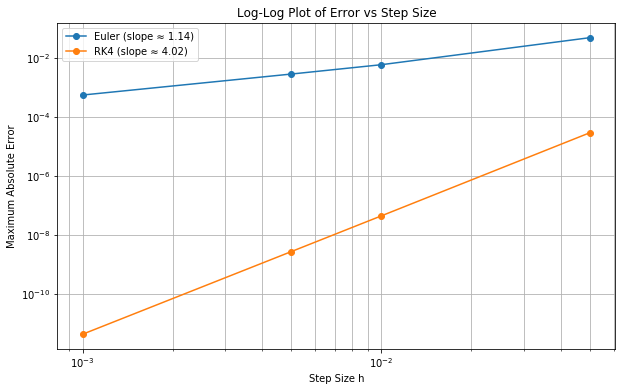

In [9]:

# Exact analytical solution

def exact_solution(t):

    return np.exp(-2 * t) * (
        0.10 * np.cos(np.sqrt(56) * t)
        +
        (0.20 / np.sqrt(56)) * np.sin(np.sqrt(56) * t)
    )


# Store maximum errors

euler_errors = []
rk4_errors = []


# Compute errors

for result in results[:len(results)//2]:   #checks convergence for the stable step sizes

    h = result[0]

    t_euler, y_euler, v_euler = result[1]
    t_rk4, y_rk4, v_rk4 = result[2]


    # Exact solutions
    y_exact_euler = exact_solution(t_euler)
    y_exact_rk4 = exact_solution(t_rk4)


    # Absolute errors
    euler_error = np.abs(y_euler - y_exact_euler)
    rk4_error = np.abs(y_rk4 - y_exact_rk4)


    # Store max error
    euler_errors.append(np.max(euler_error))
    rk4_errors.append(np.max(rk4_error))


# Compute convergence slopes

euler_slope = np.polyfit(np.log(step_sizes[:len(step_sizes)//2]), np.log(euler_errors), 1)[0]

rk4_slope = np.polyfit(np.log(step_sizes[:len(step_sizes)//2]), np.log(rk4_errors), 1)[0]


print(f"Euler convergence slope: {euler_slope:.4f}")
print(f"RK4 convergence slope: {rk4_slope:.4f}")


# Log-log plot

plt.figure(figsize=(10, 6))

plt.loglog(step_sizes[:len(step_sizes)//2], euler_errors, 'o-', label=f"Euler (slope ≈ {euler_slope:.2f})")

plt.loglog(step_sizes[:len(step_sizes)//2], rk4_errors, 'o-', label=f"RK4 (slope ≈ {rk4_slope:.2f})")

plt.xlabel("Step Size h")
plt.ylabel("Maximum Absolute Error")

plt.title("Log-Log Plot of Error vs Step Size")

plt.legend()

plt.grid(True, which="both")

plt.show()

### Phase Portrait (for those who are curious)

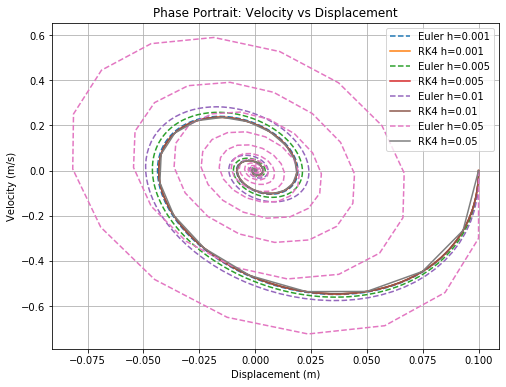

In [10]:
plt.figure(figsize=(8, 6))

for result in results[:len(results)//2]:  # stable runs only

    h = result[0]

    t_euler, y_euler, v_euler = result[1]
    t_rk4, y_rk4, v_rk4 = result[2]

    plt.plot(y_euler, v_euler, linestyle="--", label=f"Euler h={h}")

    plt.plot(y_rk4, v_rk4, label=f"RK4 h={h}")

plt.title("Phase Portrait: Velocity vs Displacement")
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

# Section 6: Conclusions

In this project, Euler’s Forward Method and the fourth-order Runge-Kutta (RK4) method were used to solve the spring-mass-damper system for multiple step sizes. Overall, RK4 performed significantly better for this problem. For stable step sizes, the RK4 solutions remained nearly identical across different values of \(h\) and closely matched the analytical solution. Euler’s Method produced reasonable results for sufficiently small step sizes, but its solutions showed noticeably larger numerical error and became unstable more quickly as the step size increased.

The comparison between computational cost and accuracy revealed an important tradeoff between the two methods. Euler’s Method is computationally inexpensive because it only evaluates the derivative once per step. However, this simplicity comes at the cost of lower accuracy and reduced stability. To obtain reliable results, Euler’s Method required very small step sizes, which increased the total number of iterations needed in the simulation. RK4 requires four derivative evaluations per step, making each iteration more computationally expensive, but the method achieved much higher accuracy and stability even for moderately larger step sizes. As a result, RK4 was more efficient overall because accurate solutions could be obtained without using extremely small step sizes.

Based on the results of this project, RK4 is the more practical numerical method for solving oscillatory engineering systems such as spring-mass-damper models. Euler’s Method can still be useful for understanding the fundamentals of numerical integration or for quick approximations, but it is not reliable for larger step sizes in systems with oscillatory behavior. Choosing an appropriate step size was also shown to be critical, since unstable step sizes produced non-physical results that violated the expected damping behavior of the system.

One of the main lessons learned from this project was that numerical methods are strongly connected to the physical behavior of the system being modeled. Even when the governing differential equation is correct, an inappropriate numerical method or step size can produce unrealistic results such as artificial energy growth or unstable oscillations. This project also demonstrated the importance of stability analysis, error analysis, and convergence testing when evaluating numerical solutions to differential equations.

### Notes and Citation
AI was used in the completion of this project. Many of the prompts used involved formatting the graphs so that they look presentable. The computation of convergence slopes and plotting of the log-log scale error plot was done by AI and so was the Phase Plane Portrait.